# M9.2B — End-to-end GAP + geometry, Fourier vs pooled overlay

Plan: [`plans/milestone_09/09_camera_view_fusion_plan.md`](../../plans/milestone_09/09_camera_view_fusion_plan.md).  
**Canonical narrative:** Final Report **M9 Step 2**. This notebook is the **pooled e2e** ladder and the combined Fourier-vs-GAP figure.

**Conclusion:** Under e2e training, GAP fusion heads match or beat Fourier; the Fourier edge remains on non-learned controls.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_09 import describe_paths, m9_corpus_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
READ_CHECKPOINTS = True
cfg_paths = m9_corpus_paths(ROOT, data_mode=DATA_MODE, read_checkpoints=READ_CHECKPOINTS)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(cfg_paths))
print(f"results_dir={display_path(cfg_paths['results_dir'])}")
print(
    f"epochs={cfg_paths['num_epochs']}  stride={cfg_paths['angle_stride_deg']}  "
    f"load_existing={cfg_paths['load_existing']}"
)


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache
results_dir=checkpoints/m9
epochs=200  stride=60.0  load_existing=True


In [3]:
from IPython.display import display

from tomography_ml import get_device
from tomography_ml_validation.milestone_09 import M9E2EConfig, run_m9_e2e_geometry_fusion_family
from tomography_ml_validation.plotting import (
    plot_m9_e2e_param_counts_fourier_vs_pooled,
    plot_m9_e2e_rmse_fourier_vs_pooled,
    plot_m9_e2e_rmse_ladder,
)

device = get_device()
print(f"device={device}")


device=mps


## Pooled e2e family, then overlay 09_2A


M9 e2e pooled: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.001  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_e2e_pooled_geometry_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_e2e_pooled_geometry_fusion.pt (8 comparison rows)


,variant_id,display_label,fusion_pattern,backbone_kind,n_views,split,encoder_frozen,geometry_tokens,fusion_hidden,fusion_depth,RMSE_total,RMSE_X,RMSE_Y,RMSE_Z,learned_parameter_count,fusion_parameter_count
0,f2b_single_view_pooled_reference,SV pooled,single_view_pooled_reference,pooled,1,test,False,False,NaN,NaN,1.983187,2.727578,1.656099,1.271512,32003,NaN
1,f2b_shared_xyz_mean_pooled_control,xyz mean pooled,shared_xyz_mean,pooled,6,test,True,False,NaN,NaN,1.678427,2.277879,1.510956,0.989764,32003,NaN
2,m09_2_e2e_pooled_geometry_fusion,09_2 compact pooled,e2e_pooled_geometry_fusion,pooled,6,test,False,True,128.0,1.0,0.860746,0.770357,0.822486,0.976071,132358,100355.0
3,m09_3_e2e_pooled_geometry_large_fusion,09_3 large pooled,e2e_pooled_geometry_large_fusion,pooled,6,test,False,True,512.0,2.0,0.941117,0.888550,1.045430,0.880146,696070,664067.0
4,f2b_single_view_pooled_reference,SV pooled,single_view_pooled_reference,pooled,1,validation,False,False,NaN,NaN,2.250423,2.781155,2.088508,1.759696,32003,NaN
5,f2b_shared_xyz_mean_pooled_control,xyz mean pooled,shared_xyz_mean,pooled,6,validation,True,False,NaN,NaN,1.903379,2.643056,1.399220,1.387443,32003,NaN
6,m09_2_e2e_pooled_geometry_fusion,09_2 compact pooled,e2e_pooled_geometry_fusion,pooled,6,validation,False,True,128.0,1.0,1.320252,1.819778,0.947075,1.010275,132358,100355.0
7,m09_3_e2e_pooled_geometry_large_fusion,09_3 large pooled,e2e_pooled_geometry_large_fusion,pooled,6,validation,False,True,512.0,2.0,1.115771,1.483069,0.898026,0.853752,696070,664067.0


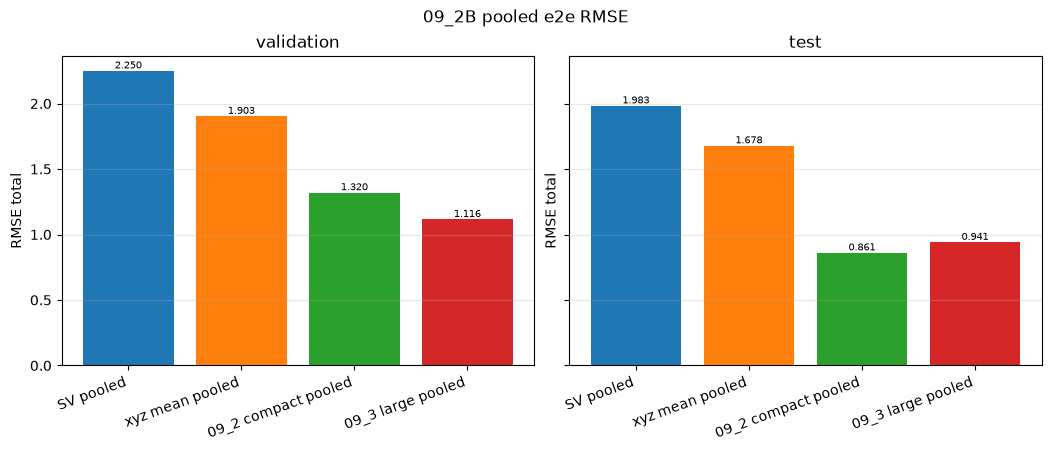

M9 e2e fourier: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.03  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_e2e_fourier_geometry_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_e2e_fourier_geometry_fusion.pt (8 comparison rows)


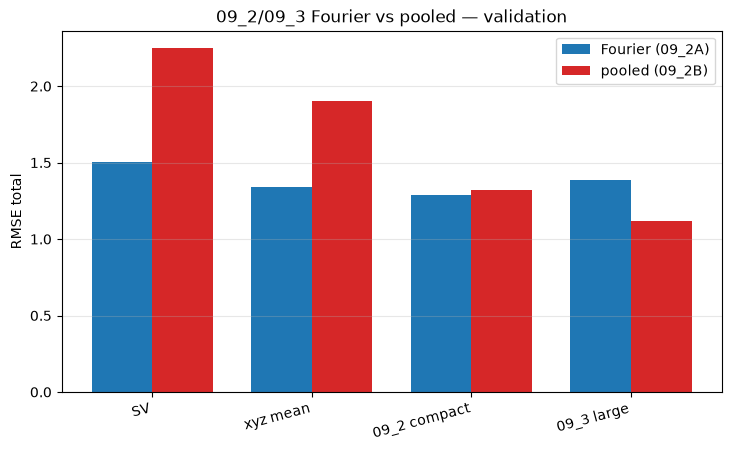

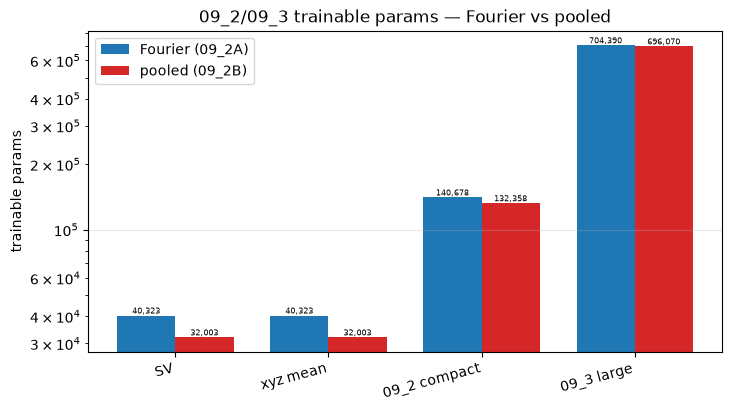

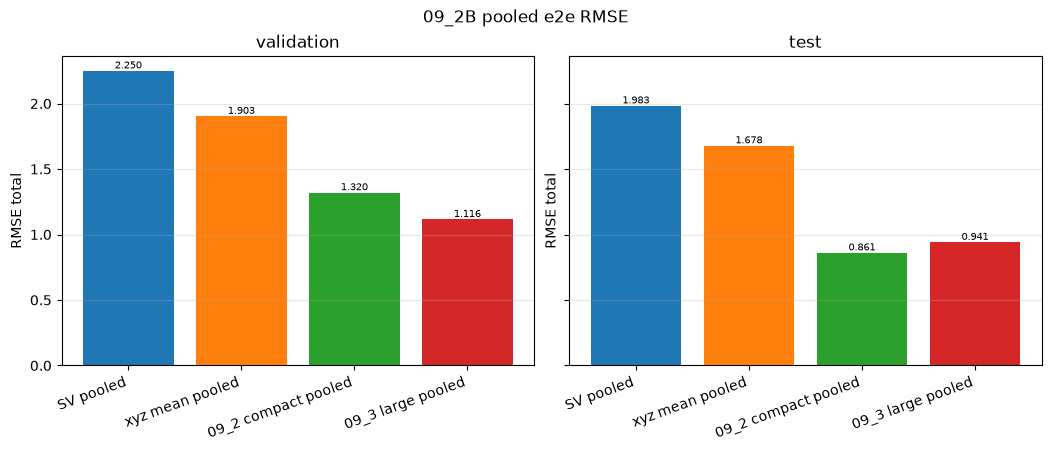

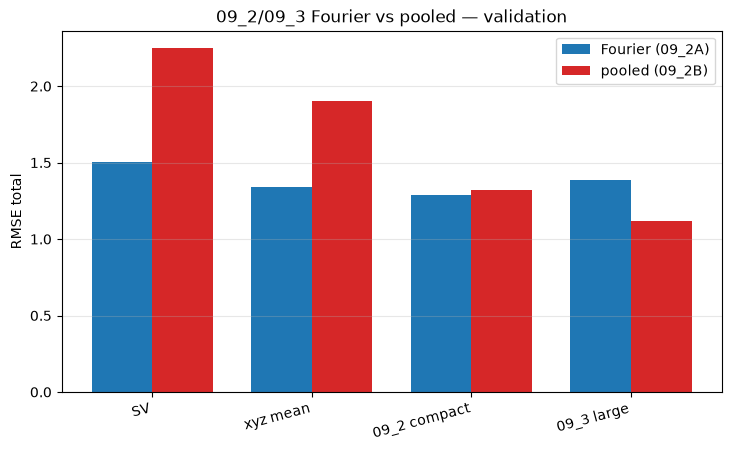

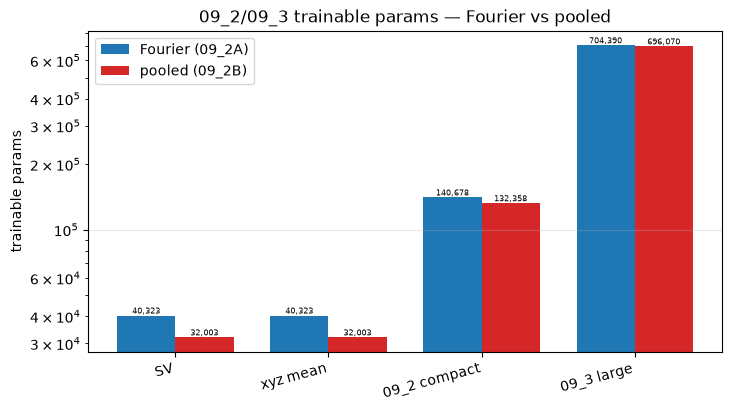

In [4]:
pooled = run_m9_e2e_geometry_fusion_family(
    M9E2EConfig(
        family="pooled",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        load_existing=cfg_paths["load_existing"],
        retrain=cfg_paths["retrain"],
    )
)
display(pooled.comparison_df)
display(plot_m9_e2e_rmse_ladder(pooled.comparison_df, family="pooled", title="09_2B pooled e2e RMSE"))

fourier = run_m9_e2e_geometry_fusion_family(
    M9E2EConfig(
        family="fourier",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        load_existing=True,
        retrain=False,
    )
)
fig_rmse = plot_m9_e2e_rmse_fourier_vs_pooled(
    fourier.comparison_df, pooled.comparison_df, split="validation"
)
if fig_rmse is not None:
    display(fig_rmse)
fig_params = plot_m9_e2e_param_counts_fourier_vs_pooled(
    fourier.comparison_df, pooled.comparison_df
)
if fig_params is not None:
    display(fig_params)


Run `09_2A` first if Fourier e2e artifacts are missing. Interpretation: Final Report M9 Step 2.
